<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Supervised Learning: Multiple Linear Regression
import numpy as np


# ============================================================
# Multiple Linear Regression
# Normal Equation
# ============================================================

class MultipleLinearRegressionNormal:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Add intercept column
        X_b = np.c_[
            np.ones((X.shape[0], 1)),
            X
        ]

        # Normal Equation
        #
        # theta = (X^T X)^(-1) X^T y

        theta = np.linalg.solve(
            X_b.T @ X_b,
            X_b.T @ y
        )
        '''np.linalg.solve() is generally more numerically stable
        and efficient than .inv() for solving this system'''

        # Intercept
        self.intercept_ = theta[0]

        # Coefficients
        self.coef_ = theta[1:]

        return self

    # ========================================================
    # Predict
    # ========================================================

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        return X @ self.coef_ + self.intercept_

    # ========================================================
    # R² Score
    # ========================================================

    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum(
            (y - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        return 1 - (ss_res / ss_tot)

In [10]:
import numpy as np


# ============================================================
# Multiple Linear Regression
# Gradient Descent
# ============================================================

class MultipleLinearRegressionGD:

    def __init__(
        self,
        learning_rate=0.01,
        n_iterations=1000
    ):

        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape

        # Initialize coefficients
        self.coef_ = np.zeros(n_features)

        # Initialize intercept
        self.intercept_ = 0.0

        # ====================================================
        # Gradient Descent
        # ====================================================

        for i in range(self.n_iterations):

            # Prediction
            y_pred = (
                X @ self.coef_
                + self.intercept_
            )

            # Error
            error = y_pred - y

            # Gradient of coefficients
            dw = (
                1 / n_samples
            ) * (X.T @ error)

            # Gradient of intercept
            db = (
                1 / n_samples
            ) * np.sum(error)

            # Update coefficients
            self.coef_ -= (
                self.learning_rate * dw
            )

            # Update intercept
            self.intercept_ -= (
                self.learning_rate * db
            )

        return self

    def predict(self, X):

        X = np.asarray(X, dtype=float)

        return (
            X @ self.coef_
            + self.intercept_
        )

    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum(
            (y - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        return 1 - (ss_res / ss_tot)

In [11]:
# ============================================================
# Dataset
# ============================================================

# Features:
#
# X1 = Hours Studied
# X2 = Hours Slept
# X3 = Practice Tests

X = np.array([
    [1, 7, 1],
    [2, 7, 2],
    [3, 6, 2],
    [4, 6, 3],
    [5, 5, 3],
    [6, 5, 4],
    [7, 4, 4],
    [8, 4, 5]
])

# Target
# Exam Score

y = np.array([
    50,
    55,
    60,
    65,
    70,
    75,
    80,
    85
])

In [16]:
import time


# ============================================================
# Train Normal Equation
# ============================================================

normal_model = MultipleLinearRegressionNormal()

start_time = time.perf_counter()

normal_model.fit(X, y)

normal_time = time.perf_counter() - start_time


# ============================================================
# Train Gradient Descent
# ============================================================

gd_model = MultipleLinearRegressionGD(
    learning_rate=0.01,
    n_iterations=1000
)

start_time = time.perf_counter()

gd_model.fit(X, y)

gd_time = time.perf_counter() - start_time


# ============================================================
# Predictions
# ============================================================

normal_pred = normal_model.predict(X)

gd_pred = gd_model.predict(X)


# ============================================================
# Accuracy Metrics
# ============================================================

normal_r2 = normal_model.score(X, y)

gd_r2 = gd_model.score(X, y)

normal_mse = np.mean(
    (y - normal_pred) ** 2
)

gd_mse = np.mean(
    (y - gd_pred) ** 2
)


# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("MULTIPLE LINEAR REGRESSION COMPARISON")
print("=" * 70)


print("\nNormal Equation")
print("-" * 30)

print(
    "Intercept :",
    normal_model.intercept_
)

print(
    "Coefficients :",
    normal_model.coef_
)

print(
    "R² Score :",
    normal_r2
)

print(
    "MSE :",
    normal_mse
)

print(
    "Training Time :",
    normal_time,
    "seconds"
)


# Prediction for a new sample
#
# [Hours Studied, Hours Slept, Practice Tests]

X_new = np.array([
    [6, 7, 4]
])

print(
    "Prediction :",
    normal_model.predict(X_new)
)


print("\nGradient Descent")
print("-" * 30)

print(
    "Intercept :",
    gd_model.intercept_
)

print(
    "Coefficients :",
    gd_model.coef_
)

print(
    "R² Score :",
    gd_r2
)

print(
    "MSE :",
    gd_mse
)

print(
    "Training Time :",
    gd_time,
    "seconds"
)

print(
    "Prediction :",
    gd_model.predict(X_new)
)


# ============================================================
# Comparison Table
# ============================================================

print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print(
    f"{'Metric':<20}"
    f"{'Normal Equation':<20}"
    f"{'Gradient Descent':<20}"
)

print("-" * 70)

print(
    f"{'R² Score':<20}"
    f"{normal_r2:<20.6f}"
    f"{gd_r2:<20.6f}"
)

print(
    f"{'MSE':<20}"
    f"{normal_mse:<20.6f}"
    f"{gd_mse:<20.6f}"
)

print(
    f"{'Training Time':<20}"
    f"{normal_time:<20.8f}"
    f"{gd_time:<20.8f}"
)

MULTIPLE LINEAR REGRESSION COMPARISON

Normal Equation
------------------------------
Intercept : 29.999999999996586
Coefficients : [ 7.14285714  2.14285714 -2.14285714]
R² Score : 1.0
MSE : 5.679798517591285e-27
Training Time : 0.0002226799999789364 seconds
Prediction : [79.28571429]

Gradient Descent
------------------------------
Intercept : 1.776211607463466
Coefficients : [7.39606278 5.58768868 0.55027021]
R² Score : 0.9828659678176276
MSE : 2.2488417239363834
Training Time : 0.010422932999972545 seconds
Prediction : [87.46748989]

COMPARISON
Metric              Normal Equation     Gradient Descent    
----------------------------------------------------------------------
R² Score            1.000000            0.982866            
MSE                 0.000000            2.248842            
Training Time       0.00022268          0.01042293          


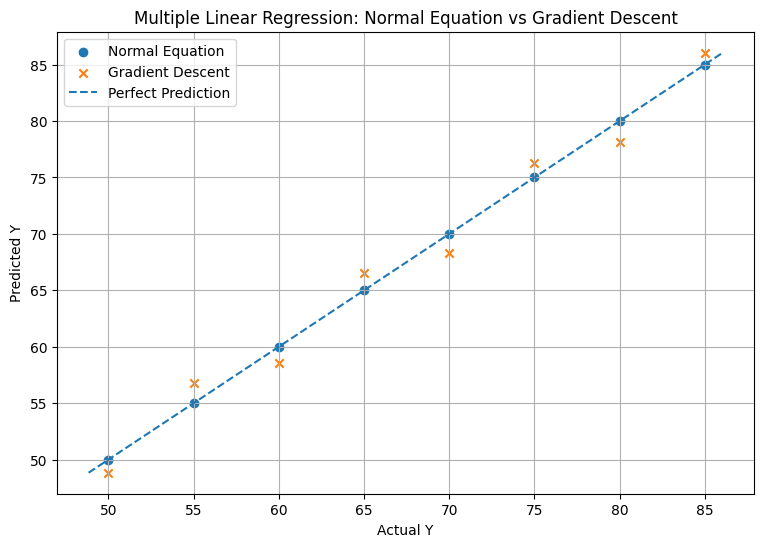

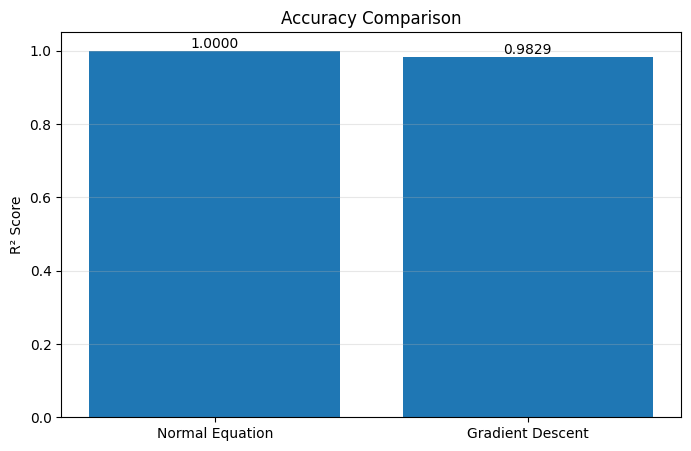

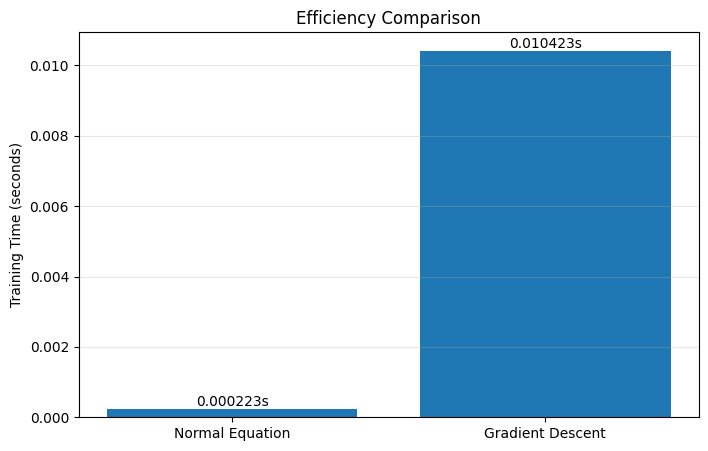

In [17]:
import matplotlib.pyplot as plt


# ============================================================
# Plot 1: Actual vs Predicted Values
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y,
    normal_pred,
    label="Normal Equation"
)

plt.scatter(
    y,
    gd_pred,
    marker="x",
    label="Gradient Descent"
)

# Perfect prediction line
min_value = min(
    y.min(),
    normal_pred.min(),
    gd_pred.min()
)

max_value = max(
    y.max(),
    normal_pred.max(),
    gd_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")

plt.title(
    "Multiple Linear Regression: "
    "Normal Equation vs Gradient Descent"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Plot 2: Accuracy Comparison
# ============================================================

methods = [
    "Normal Equation",
    "Gradient Descent"
]

r2_scores = [
    normal_r2,
    gd_r2
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    r2_scores
)

plt.ylabel("R² Score")

plt.title(
    "Accuracy Comparison"
)

plt.ylim(0, 1.05)

for bar, value in zip(
    bars,
    r2_scores
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# Plot 3: Efficiency Comparison
# ============================================================

training_times = [
    normal_time,
    gd_time
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    training_times
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Efficiency Comparison"
)

for bar, value in zip(
    bars,
    training_times
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:.6f}s",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()